In [1]:
import numpy as np

# Load embeddings
embeddings_np = np.load('image_embeddings.npy')

# Load processed image paths and captions
processed_image_paths = np.load('processed_image_paths.npy', allow_pickle=True)
processed_captions = np.load('processed_captions.npy', allow_pickle=True)

In [2]:
import faiss

# Normalize embeddings (if using cosine similarity)
faiss.normalize_L2(embeddings_np)

# Build FAISS index
index = faiss.IndexFlatIP(embeddings_np.shape[1])  # Inner product for cosine similarity
index.add(embeddings_np)

print(f"FAISS index contains {index.ntotal} vectors.")

FAISS index contains 3272 vectors.


In [3]:
def retrieve_similar_images(query_embedding, index, k=5):
    # Normalize query embedding
    query_embedding = query_embedding.astype('float32')
    faiss.normalize_L2(query_embedding)

    # Perform search
    distances, indices = index.search(query_embedding, k)
    return distances[0], indices[0]

Query Image:


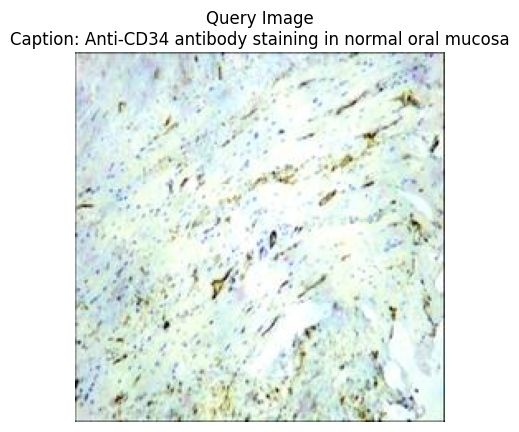

Top 5 similar images:


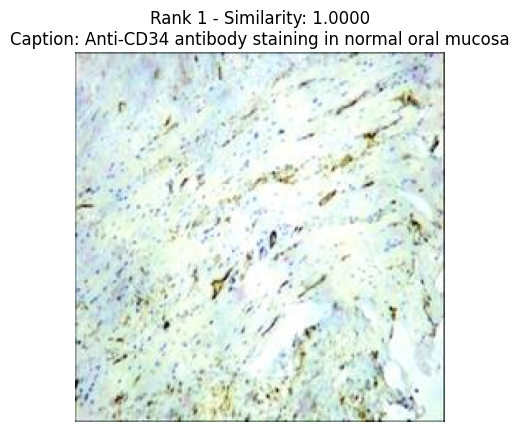

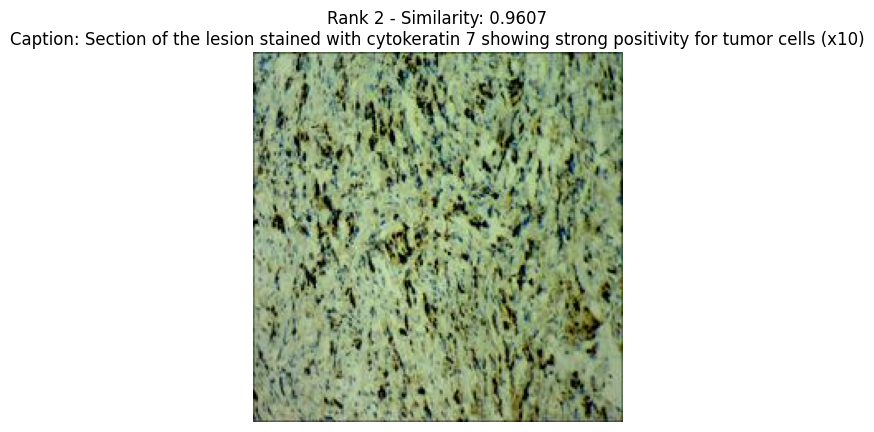

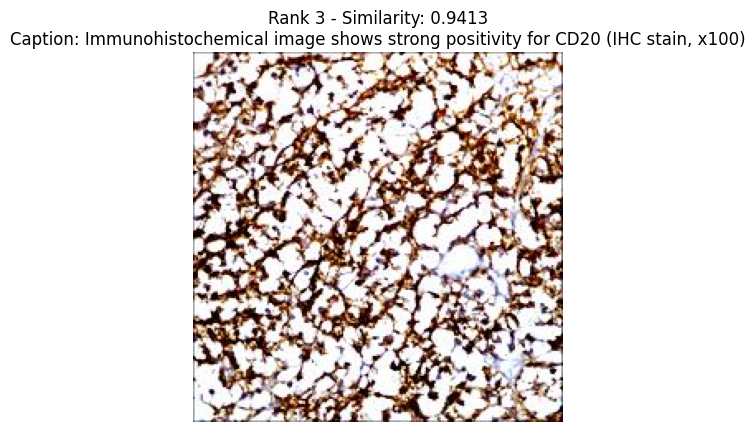

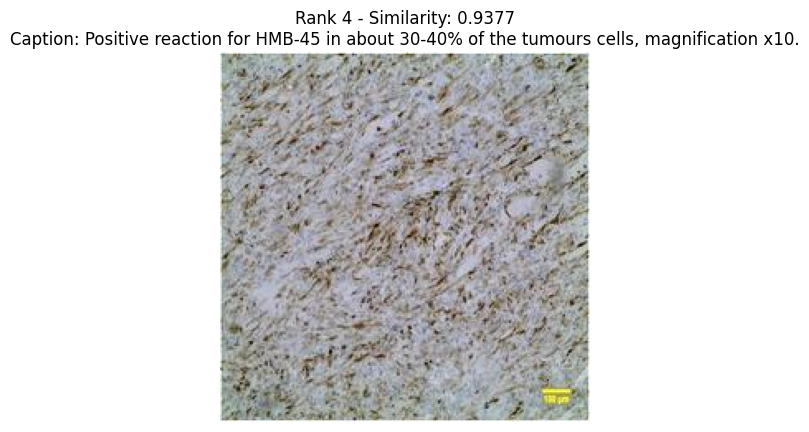

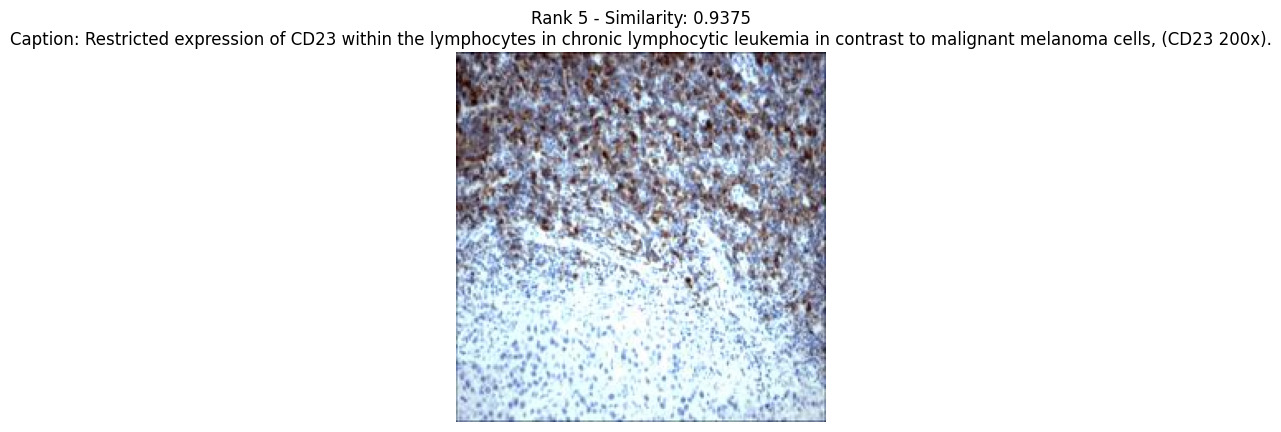

In [5]:
import random
from PIL import Image
import matplotlib.pyplot as plt

# Select a random query image from the processed list
query_idx = random.randint(0, len(processed_image_paths) - 1)
query_image_path = processed_image_paths[query_idx]
query_caption = processed_captions[query_idx]

# Get query embedding
query_embedding = embeddings_np[query_idx].reshape(1, -1)

# Retrieve similar images
k = 5
distances, indices = retrieve_similar_images(query_embedding, index, k)

# Display query image
print("Query Image:")
display_image = Image.open(query_image_path)
plt.imshow(display_image)
plt.title(f"Query Image\nCaption: {query_caption}")
plt.axis('off')
plt.show()
plt.close()             # Close the plot
display_image.close()   # Close the image

# Display retrieved images
print(f"Top {k} similar images:")
for rank, idx in enumerate(indices):
    retrieved_image_path = processed_image_paths[idx]
    retrieved_caption = processed_captions[idx]
    similarity = distances[rank]

    # Display image
    retrieved_image = Image.open(retrieved_image_path)
    plt.imshow(retrieved_image)
    plt.title(f"Rank {rank + 1} - Similarity: {similarity:.4f}\nCaption: {retrieved_caption}")
    plt.axis('off')
    plt.show()
    plt.close()              # Close the plot
    retrieved_image.close()  # Close the image